In [1]:
# Install required libraries

!pip install pandas nltk matplotlib wordcloud textblob scikit-learn

In [2]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

from collections import Counter
from wordcloud import WordCloud

In [3]:
# Download NLTK Resources

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [4]:
import random

# -----------------------------
# Review Templates
# -----------------------------

positive_food = [
    "The food was delicious and fresh.","Amazing biryani with excellent taste.","Pizza was perfectly cooked.","Loved the burger and fries.",
    "Food quality exceeded expectations.","The pasta was creamy and tasty.","Chicken was juicy and flavorful.","Fresh ingredients and wonderful taste.",
    "Best restaurant I have visited.","The dessert was absolutely amazing.","Food arrived hot and delicious.","Excellent quality and generous portions.",
    "Everything tasted fresh.","Authentic flavors and great presentation.","Highly recommend this restaurant.","The sushi was fresh and delicious.",
    "Perfect seasoning and rich flavors.","Fantastic meal with excellent quality.","Very satisfying dinner.","The chef did an amazing job."
]

negative_food = [
    "The food was cold.","Pizza was soggy.","Burger tasted stale.","The biryani lacked flavor.","Food was overcooked.",
    "The meal was undercooked.","The soup was too salty.","The food smelled bad.","Portion size was too small.","The food was disappointing.",
    "Very poor food quality.","Rice was dry and hard.","The chicken was rubbery.","The food was burnt.","Worst meal ever.",
    "Food was bland and tasteless.","Ingredients were not fresh.","Meal was oily.","The noodles were sticky.","Completely ruined my appetite."
]

neutral_food = [
    "Food was okay.","Taste was average.","Nothing special about the meal.","The food was acceptable.","Average quality food.",
    "Meal was decent.","Food was neither good nor bad.","The restaurant served normal food.","Taste was satisfactory.","The meal met expectations.",
    "Food quality was acceptable.","Nothing impressive.","Average dining experience.","Meal was fine.","Food was as expected."
]

positive_delivery = [
    "Delivery was very fast.","Food arrived on time.","Quick delivery service.","Delivery executive was polite.",
    "Order arrived earlier than expected.","Fast and reliable delivery.","Prompt delivery.","Excellent delivery experience.","Very quick doorstep delivery.",
    "Delivery exceeded expectations."
]

negative_delivery = [
    "Delivery was very late.",
    "Food arrived after one hour.",
    "Delivery person was rude.",
    "Order was delayed.",
    "Terrible delivery experience.",
    "Very slow delivery.",
    "Delivery was unacceptable.",
    "Wrong order was delivered.",
    "Package arrived damaged.",
    "Delivery tracking was inaccurate."
]

neutral_delivery = [
    "Delivery was normal.","Delivery timing was acceptable.","Order arrived as expected.","Average delivery speed.","No issues with delivery."
]

positive_service = [
    "Friendly staff.","Excellent customer service.","Very polite employees.","Helpful restaurant staff.",
    "Professional behavior.","Staff were welcoming.","Manager handled everything perfectly.","Customer support was responsive."
]

negative_service = [
    "Staff were rude.","Poor customer service.","Employees ignored customers.","Very disappointing service.",
    "Manager was unhelpful.","Support team never responded.","Staff behaved unprofessionally.","Terrible customer handling."
]

neutral_service = [
    "Customer service was average.","Staff behavior was okay.","Nothing unusual about the service.","Service was acceptable.","Employees were normal."
]

positive_price = [
    "Good value for money.","Affordable prices.","Reasonable pricing.","Worth every penny.","Fair pricing."
]

negative_price = [
    "Very expensive.","Not worth the price.","Overpriced food.","Price was too high.","Cost was unreasonable."
]

neutral_price = [
    "Price was acceptable.","Pricing was average.","Cost was reasonable.","Price matched the quality.","Nothing unusual about the price."
]

In [5]:
reviews = []
ratings = []

In [6]:
for _ in range(500):

    review = " ".join([
        random.choice(positive_food),
        random.choice(positive_delivery),
        random.choice(positive_service),
        random.choice(positive_price)
    ])

    reviews.append(review)

    ratings.append(random.choice([4, 5]))

print("Positive reviews generated:", len(reviews))

Positive reviews generated: 500


In [7]:
# Generate 300 Negative Reviews

for _ in range(300):

    review = " ".join([
        random.choice(negative_food),
        random.choice(negative_delivery),
        random.choice(negative_service),
        random.choice(negative_price)
    ])

    reviews.append(review)

    ratings.append(random.choice([1, 2]))

print("Total reviews after adding negatives:", len(reviews))

Total reviews after adding negatives: 800


In [8]:
# Generate 200 Neutral Reviews

for _ in range(200):

    review = " ".join([
        random.choice(neutral_food),
        random.choice(neutral_delivery),
        random.choice(neutral_service),
        random.choice(neutral_price)
    ])

    reviews.append(review)

    ratings.append(3)

print("Total reviews after adding neutrals:", len(reviews))

Total reviews after adding neutrals: 1000


In [9]:
# Shuffle the dataset

combined = list(zip(reviews, ratings))

random.shuffle(combined)

reviews, ratings = zip(*combined)

print("Dataset shuffled successfully.")

Dataset shuffled successfully.


In [10]:
# Create the DataFrame

df = pd.DataFrame({"Review": reviews,"Rating": ratings})
df.head()

,Review,Rating
0,Food was okay. Average delivery speed. Employe...,3
1,Authentic flavors and great presentation. Prom...,5
2,The chef did an amazing job. Delivery was very...,4
3,Meal was fine. Delivery was normal. Nothing un...,3
4,The noodles were sticky. Terrible delivery exp...,2


In [11]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (1000, 2)


In [12]:
# Display 10 random reviews

df.sample(10)

,Review,Rating
568,The food was cold. Delivery person was rude. T...,2
94,The biryani lacked flavor. Package arrived dam...,2
621,The sushi was fresh and delicious. Fast and re...,5
213,Loved the burger and fries. Order arrived earl...,5
905,Average dining experience. Average delivery sp...,3
822,Average quality food. Delivery was normal. Sta...,3
191,Meal was oily. Very slow delivery. Employees i...,1
419,Chicken was juicy and flavorful. Food arrived ...,4
544,Food quality was acceptable. Delivery timing w...,3
799,Portion size was too small. Order was delayed....,2


In [13]:
df["Rating"].value_counts().sort_index()

,count
Rating,
1,160
2,140
3,200
4,243
5,257


In [14]:
print("Duplicate Reviews:", df.duplicated().sum())

Duplicate Reviews: 16


In [16]:
# HERE DUPLICATES ARE THERE SO REMOVING THE DUPLICATED REVIEWS

df = df.drop_duplicates()
print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (984, 2)


In [17]:
# Count the number of words in each review

df["Review_Length"] = df["Review"].apply(lambda x: len(x.split()))
df.head()

,Review,Rating,Review_Length
0,Food was okay. Average delivery speed. Employe...,3,12
1,Authentic flavors and great presentation. Prom...,5,14
2,The chef did an amazing job. Delivery was very...,4,16
3,Meal was fine. Delivery was normal. Nothing un...,3,15
4,The noodles were sticky. Terrible delivery exp...,2,13


In [18]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

In [19]:
def preprocess(text):
  text = text.lower()
  text = re.sub(r"\d+", "", text)
  text = text.translate(str.maketrans("", "", string.punctuation))
  words = text.split()
  words = [
      lemmatizer.lemmatize(word)
      for word in words
      if word not in stop_words
  ]

  return " ".join(words)

In [20]:
# Apply preprocessing

df["Cleaned_Review"] = df["Review"].apply(preprocess)
df.head()

,Review,Rating,Review_Length,Cleaned_Review
0,Food was okay. Average delivery speed. Employe...,3,12,food okay average delivery speed employee norm...
1,Authentic flavors and great presentation. Prom...,5,14,authentic flavor great presentation prompt del...
2,The chef did an amazing job. Delivery was very...,4,16,chef amazing job delivery fast excellent custo...
3,Meal was fine. Delivery was normal. Nothing un...,3,15,meal fine delivery normal nothing unusual serv...
4,The noodles were sticky. Terrible delivery exp...,2,13,noodle sticky terrible delivery experience emp...


In [21]:
# Compare original and cleaned reviews

df[["Review", "Cleaned_Review"]].head(10)

,Review,Cleaned_Review
0,Food was okay. Average delivery speed. Employe...,food okay average delivery speed employee norm...
1,Authentic flavors and great presentation. Prom...,authentic flavor great presentation prompt del...
2,The chef did an amazing job. Delivery was very...,chef amazing job delivery fast excellent custo...
3,Meal was fine. Delivery was normal. Nothing un...,meal fine delivery normal nothing unusual serv...
4,The noodles were sticky. Terrible delivery exp...,noodle sticky terrible delivery experience emp...
5,Completely ruined my appetite. Very slow deliv...,completely ruined appetite slow delivery staff...
6,Best restaurant I have visited. Very quick doo...,best restaurant visited quick doorstep deliver...
7,The noodles were sticky. Package arrived damag...,noodle sticky package arrived damaged staff be...
8,Very satisfying dinner. Delivery executive was...,satisfying dinner delivery executive polite pr...
9,The restaurant served normal food. Delivery ti...,restaurant served normal food delivery timing ...


SENTIMENT ANALYSIS

In [22]:
sia = SentimentIntensityAnalyzer()

In [23]:
def get_sentiment(review):

    score = sia.polarity_scores(review)["compound"]

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"

In [24]:
df["Sentiment"] = df["Review"].apply(get_sentiment)

df.head()

,Review,Rating,Review_Length,Cleaned_Review,Sentiment
0,Food was okay. Average delivery speed. Employe...,3,12,food okay average delivery speed employee norm...,Positive
1,Authentic flavors and great presentation. Prom...,5,14,authentic flavor great presentation prompt del...,Positive
2,The chef did an amazing job. Delivery was very...,4,16,chef amazing job delivery fast excellent custo...,Positive
3,Meal was fine. Delivery was normal. Nothing un...,3,15,meal fine delivery normal nothing unusual serv...,Positive
4,The noodles were sticky. Terrible delivery exp...,2,13,noodle sticky terrible delivery experience emp...,Negative


In [25]:
# Counting the sentiments

df["Sentiment"].value_counts()

,count
Sentiment,
Positive,615
Negative,313
Neutral,56


In [26]:
# Displaying some reviews randomly for seeying sentiments

df[["Review","Sentiment"]].sample(15)

,Review,Sentiment
23,Meal was decent. Average delivery speed. Custo...,Neutral
710,Completely ruined my appetite. Delivery was ve...,Negative
270,Chicken was juicy and flavorful. Very quick do...,Neutral
780,Pizza was perfectly cooked. Delivery exceeded ...,Positive
257,Amazing biryani with excellent taste. Fast and...,Positive
278,Pizza was perfectly cooked. Delivery was very ...,Positive
156,Excellent quality and generous portions. Very ...,Positive
91,The food was cold. Delivery tracking was inacc...,Neutral
52,Fantastic meal with excellent quality. Deliver...,Positive
255,Ingredients were not fresh. Order was delayed....,Negative


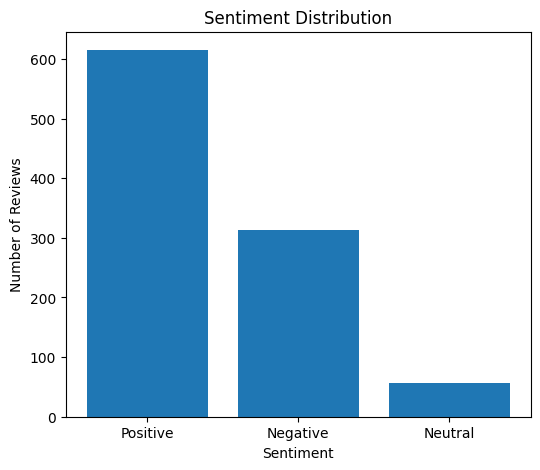

In [27]:
# VISUALIZATION

sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(sentiment_counts.index,
        sentiment_counts.values)

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.show()

In [29]:
issues = {"Delivery":["delivery","late","delay","slow","arrived"],
          "Food Quality":["cold","burnt","stale","soggy","taste","flavor","food","meal"],
          "Packaging":["package","packaging","box","spill","damaged"],
          "Customer Service":["staff","service","manager","employee","support","rude"],
          "Price":["price","cost","expensive","overpriced","affordable"]}

In [30]:
issue_counter = Counter()

for review in df["Cleaned_Review"]:
    for category, keywords in issues.items():
        if any(word in review for word in keywords):
            issue_counter[category] += 1
issue_counter

Counter({'Delivery': 963,
         'Food Quality': 634,
         'Customer Service': 894,
         'Price': 546,
         'Packaging': 26})

In [31]:
issue_df = pd.DataFrame(
    issue_counter.items(),
    columns=["Issue","Frequency"]
)
issue_df

,Issue,Frequency
0,Delivery,963
1,Food Quality,634
2,Customer Service,894
3,Price,546
4,Packaging,26


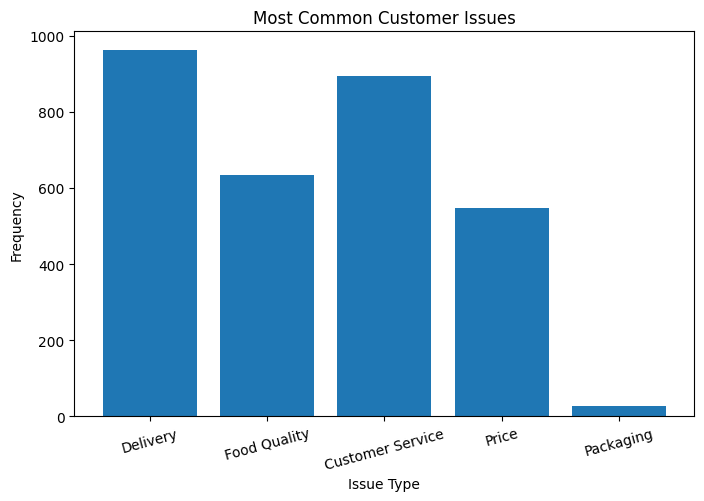

In [32]:
plt.figure(figsize=(8,5))

plt.bar(issue_df["Issue"],
        issue_df["Frequency"])

plt.title("Most Common Customer Issues")

plt.xlabel("Issue Type")

plt.ylabel("Frequency")

plt.xticks(rotation=15)

plt.show()

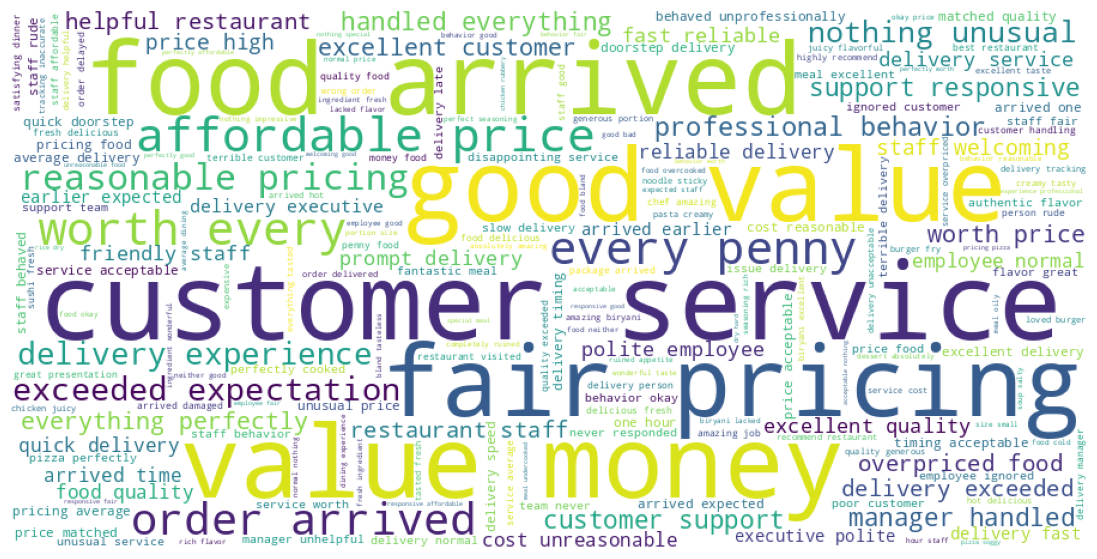

In [33]:
# GENERATING WORD CLOUD

text = " ".join(df["Cleaned_Review"])
wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="white"
).generate(text)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [34]:
words = " ".join(df["Cleaned_Review"]).split()
word_freq = Counter(words)
top20 = word_freq.most_common(20)
top20_df = pd.DataFrame(
    top20,
    columns=["Word","Frequency"])

top20_df

,Word,Frequency
0,delivery,733
1,food,407
2,price,330
3,service,298
4,staff,294
5,customer,263
6,pricing,231
7,arrived,226
8,excellent,184
9,acceptable,155


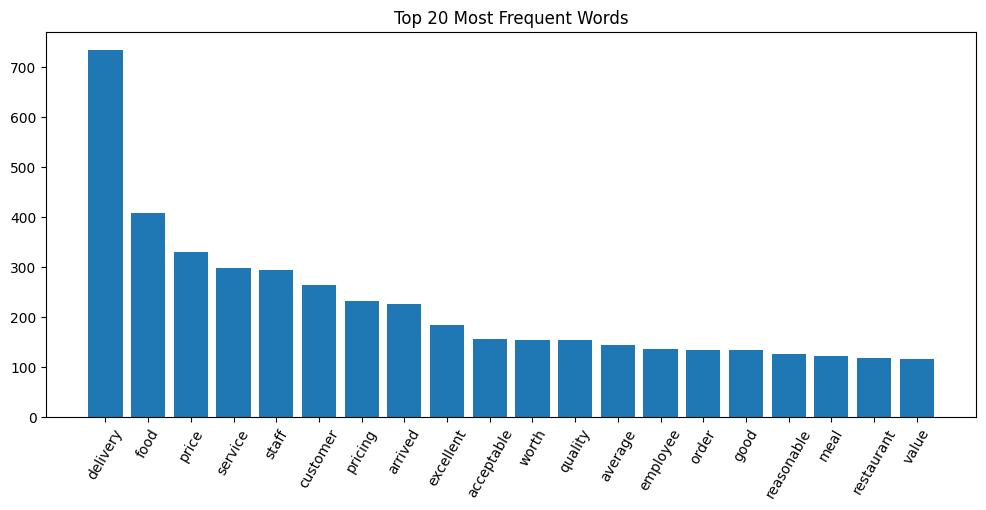

In [35]:
plt.figure(figsize=(12,5))

plt.bar(top20_df["Word"],

        top20_df["Frequency"])

plt.xticks(rotation=60)

plt.title("Top 20 Most Frequent Words")

plt.show()

In [36]:
# FEEDBACK ANALYSIS

total_reviews = len(df)
positive_reviews = len(df[df["Sentiment"]=="Positive"])
negative_reviews = len(df[df["Sentiment"]=="Negative"])
neutral_reviews = len(df[df["Sentiment"]=="Neutral"])
print("="*60)
print("        RESTAURANT FEEDBACK ANALYSIS REPORT")
print("="*60)
print(f"Total Reviews              : {total_reviews}")
print(f"Positive Reviews           : {positive_reviews}")
print(f"Negative Reviews           : {negative_reviews}")
print(f"Neutral Reviews            : {neutral_reviews}")
print()
print("Most Common Service Issues")
print("-"*30)

for issue,count in issue_counter.items():
    print(f"{issue:<20} : {count}")
print("="*60)

        RESTAURANT FEEDBACK ANALYSIS REPORT
Total Reviews              : 984
Positive Reviews           : 615
Negative Reviews           : 313
Neutral Reviews            : 56

Most Common Service Issues
------------------------------
Delivery             : 963
Food Quality         : 634
Customer Service     : 894
Price                : 546
Packaging            : 26


In [37]:
print("\nRecommendations")
print("- Improve food quality and freshness.")
print("- Reduce delivery delays.")
print("- Train customer service staff.")
print("- Improve packaging quality.")
print("- Review pricing strategy.")
print("- Continue maintaining positive customer experience.")


Recommendations
- Improve food quality and freshness.
- Reduce delivery delays.
- Train customer service staff.
- Improve packaging quality.
- Review pricing strategy.
- Continue maintaining positive customer experience.
